# 🎯 Landmark Model Training - Optimized for AMD GPU

Training model landmark untuk klasifikasi emosi menggunakan facial landmarks dengan optimasi GPU.

## 1. 📚 Import Libraries

In [39]:
import numpy as np
import tensorflow as tf
import os
import time
import pickle
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 2. 🎮 AMD GPU Setup

In [40]:
def setup_amd_gpu():
    """Setup AMD GPU with DirectML for optimal performance"""
    print("🎮 Setting up AMD GPU for Landmark Training...")
    
    try:
        gpu_devices = tf.config.list_physical_devices('GPU')
        dml_devices = tf.config.list_physical_devices('DML')
        total_devices = len(gpu_devices) + len(dml_devices)
        
        if total_devices > 0:
            print(f"✅ Found {total_devices} GPU device(s)")
            
            # Configure GPU memory growth
            for gpu in gpu_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("✅ GPU memory growth enabled")
            
            # Enable XLA compilation
            tf.config.optimizer.set_jit(True)
            print("✅ XLA compilation enabled")
            
            return True, total_devices
        else:
            print("⚠️ No GPU detected, using CPU")
            return False, 0
    except Exception as e:
        print(f"⚠️ GPU setup failed: {e}")
        return False, 0

# Setup GPU
gpu_available, num_gpus = setup_amd_gpu()

🎮 Setting up AMD GPU for Landmark Training...
✅ Found 2 GPU device(s)
✅ GPU memory growth enabled
✅ XLA compilation enabled


## 3. ⚙️ Konfigurasi Training

In [41]:
# GPU-optimized configurations
if gpu_available:
    BATCH_SIZE = 256  # Larger batch for landmarks (smaller data)
    EPOCHS = 150      # More epochs for landmarks
else:
    BATCH_SIZE = 64
    EPOCHS = 80

# Paths
BASE_PATH = 'D:/research/2025_iris_taufik/MultimodalEmoLearn/data/'
MODEL_PATH = 'D:/research/2025_iris_taufik/MultimodalEmoLearn/models/'

print(f"🎯 Landmark Training Configuration:")
print(f"   Device: {'AMD GPU' if gpu_available else 'CPU'}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max Epochs: {EPOCHS}")

🎯 Landmark Training Configuration:
   Device: AMD GPU
   Batch Size: 256
   Max Epochs: 150


## 4. 📁 Load Data

In [43]:
print("📁 Loading landmark data...")

try:
    # Load landmark features
    X_train_landmarks = np.load(BASE_PATH + 'landmarks/X_train_landmarks.npy')
    X_val_landmarks = np.load(BASE_PATH + 'landmarks/X_val_landmarks.npy')
    X_test_landmarks = np.load(BASE_PATH + 'landmarks/X_test_landmarks.npy')
    
    # Load labels
    y_train = np.load(BASE_PATH + 'landmarks/y_train_landmarks.npy')
    y_val = np.load(BASE_PATH + 'landmarks/y_val_landmarks.npy')
    y_test = np.load(BASE_PATH + 'landmarks/y_test_landmarks.npy')
    
    print(f"✅ Landmark data loaded successfully!")
    print(f"Training samples: {X_train_landmarks.shape[0]:,}")
    print(f"Validation samples: {X_val_landmarks.shape[0]:,}")
    print(f"Test samples: {X_test_landmarks.shape[0]:,}")
    print(f"Landmark features: {X_train_landmarks.shape[1]}")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit(1)

📁 Loading landmark data...
✅ Landmark data loaded successfully!
Training samples: 523
Validation samples: 65
Test samples: 66
Landmark features: 136


## 5. 🏷️ Load Label Mapping

In [44]:
print("🏷️ Loading label mapping...")

try:
    with open(MODEL_PATH + 'label_map.pkl', 'rb') as f:
        label_map = pickle.load(f)
    
    num_classes = len(label_map)
    target_names = list(label_map.keys())
    
    print(f"Classes: {target_names}")
    print(f"Number of classes: {num_classes}")
    
except FileNotFoundError:
    print("❌ Label mapping not found! Please train CNN model first.")
    exit(1)

# Convert labels
y_train_num = np.array([label_map[label] for label in y_train])
y_val_num = np.array([label_map[label] for label in y_val])
y_test_num = np.array([label_map[label] for label in y_test])

# One-hot encoding
y_train_onehot = to_categorical(y_train_num, num_classes)
y_val_onehot = to_categorical(y_val_num, num_classes)
y_test_onehot = to_categorical(y_test_num, num_classes)

print("✅ Label preprocessing completed")

🏷️ Loading label mapping...
Classes: ['angry', 'contempt', 'disgusted', 'fear', 'happy', 'neutral', 'sad', 'surprised']
Number of classes: 8
✅ Label preprocessing completed


## 6. 🧠 Build Landmark Model

In [45]:
def build_optimized_landmark_model(input_dim, num_classes):
    """Build landmark model optimized for GPU training"""
    
    device_context = '/GPU:0' if gpu_available else '/CPU:0'
    
    with tf.device(device_context):
        model = Sequential([
            # Input layer
            Dense(512 if gpu_available else 256, activation='relu', input_dim=input_dim),
            BatchNormalization(),
            Dropout(0.3),
            
            # Hidden layers - more complex for GPU
            Dense(256 if gpu_available else 128, activation='relu'),
            BatchNormalization(),
            Dropout(0.4),
            
            Dense(128 if gpu_available else 64, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            
            # Additional layer for GPU
            Dense(64, activation='relu') if gpu_available else Dense(32, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),
            
            # Output layer
            Dense(num_classes, activation='softmax')
        ])
    
    # Compile with optimized learning rate
    learning_rate = 0.001 if gpu_available else 0.01
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## 7. 🔧 Setup Callbacks

In [46]:
print("⚙️ Setting up callbacks...")

# Model checkpoint
checkpoint = ModelCheckpoint(
    MODEL_PATH + 'landmark_model_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20 if gpu_available else 15,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

# Learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10 if gpu_available else 7,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

⚙️ Setting up callbacks...


## 8. 🚀 Train Model

In [47]:
print(f"🚀 Training Landmark model on {'GPU' if gpu_available else 'CPU'}...")
print("=" * 60)

# Build model
landmark_model = build_optimized_landmark_model(X_train_landmarks.shape[1], num_classes)

print("📊 Model Summary:")
print(f"Total Parameters: {landmark_model.count_params():,}")
trainable_params = sum([tf.size(w).numpy() for w in landmark_model.trainable_weights])
print(f"Trainable Parameters: {trainable_params:,}")

# Training
start_time = time.time()

try:
    device_context = '/GPU:0' if gpu_available else '/CPU:0'
    
    with tf.device(device_context):
        landmark_history = landmark_model.fit(
            X_train_landmarks,
            y_train_onehot,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val_landmarks, y_val_onehot),
            callbacks=callbacks,
            verbose=1
        )
    
    training_time = time.time() - start_time
    print(f"✅ Training completed in {training_time/3600:.2f} hours")
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    if gpu_available and 'memory' in str(e).lower():
        print("💡 Retrying with smaller batch size...")
        BATCH_SIZE = 64
        landmark_history = landmark_model.fit(
            X_train_landmarks,
            y_train_onehot,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val_landmarks, y_val_onehot),
            callbacks=callbacks,
            verbose=1
        )

🚀 Training Landmark model on GPU...
📊 Model Summary:
Total Parameters: 246,984
Trainable Parameters: 245,064
Epoch 1/150
3/3 [==============================] - ETA: 0s - loss: 2.8179 - accuracy: 0.1453
Epoch 1: val_accuracy improved from -inf to 0.03077, saving model to D:/research/2025_iris_taufik/MultimodalEmoLearn/models\landmark_model_best.h5
3/3 [==============================] - 3s 985ms/step - loss: 2.8179 - accuracy: 0.1453 - val_loss: 59.0278 - val_accuracy: 0.0308 - lr: 0.0010
Epoch 2/150
3/3 [==============================] - ETA: 0s - loss: 2.6153 - accuracy: 0.1893
Epoch 2: val_accuracy did not improve from 0.03077
3/3 [==============================] - 0s 174ms/step - loss: 2.6153 - accuracy: 0.1893 - val_loss: 45.8575 - val_accuracy: 0.0308 - lr: 0.0010
Epoch 3/150
2/3 [===================>..........] - ETA: 0s - loss: 2.7025 - accuracy: 0.1895
Epoch 3: val_accuracy improved from 0.03077 to 0.04615, saving model to D:/research/2025_iris_taufik/MultimodalEmoLearn/models\l

## 9. 📊 Evaluation

In [48]:
print("\n📊 Evaluating model...")

# Load best model
landmark_model = load_model(MODEL_PATH + 'landmark_model_best.h5')

# Evaluate on test set
test_loss, test_acc = landmark_model.evaluate(X_test_landmarks, y_test_onehot, verbose=0)
print(f"🎯 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

# Detailed predictions
y_pred = np.argmax(landmark_model.predict(X_test_landmarks, batch_size=BATCH_SIZE), axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

# Classification report
print("\n📈 Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))


📊 Evaluating model...
🎯 Test Accuracy: 0.6212
📉 Test Loss: 6.2260
1/1 [==============================] - 0s 115ms/step

📈 Classification Report:
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         5
    contempt       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         6
        fear       0.00      0.00      0.00         2
       happy       0.00      0.00      0.00         7
     neutral       0.59      1.00      0.74        33
         sad       0.00      0.00      0.00         3
   surprised       0.80      0.89      0.84         9

    accuracy                           0.62        66
   macro avg       0.17      0.24      0.20        66
weighted avg       0.40      0.62      0.49        66



c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_

## 10. 📊 Visualization

📊 Creating visualizations...


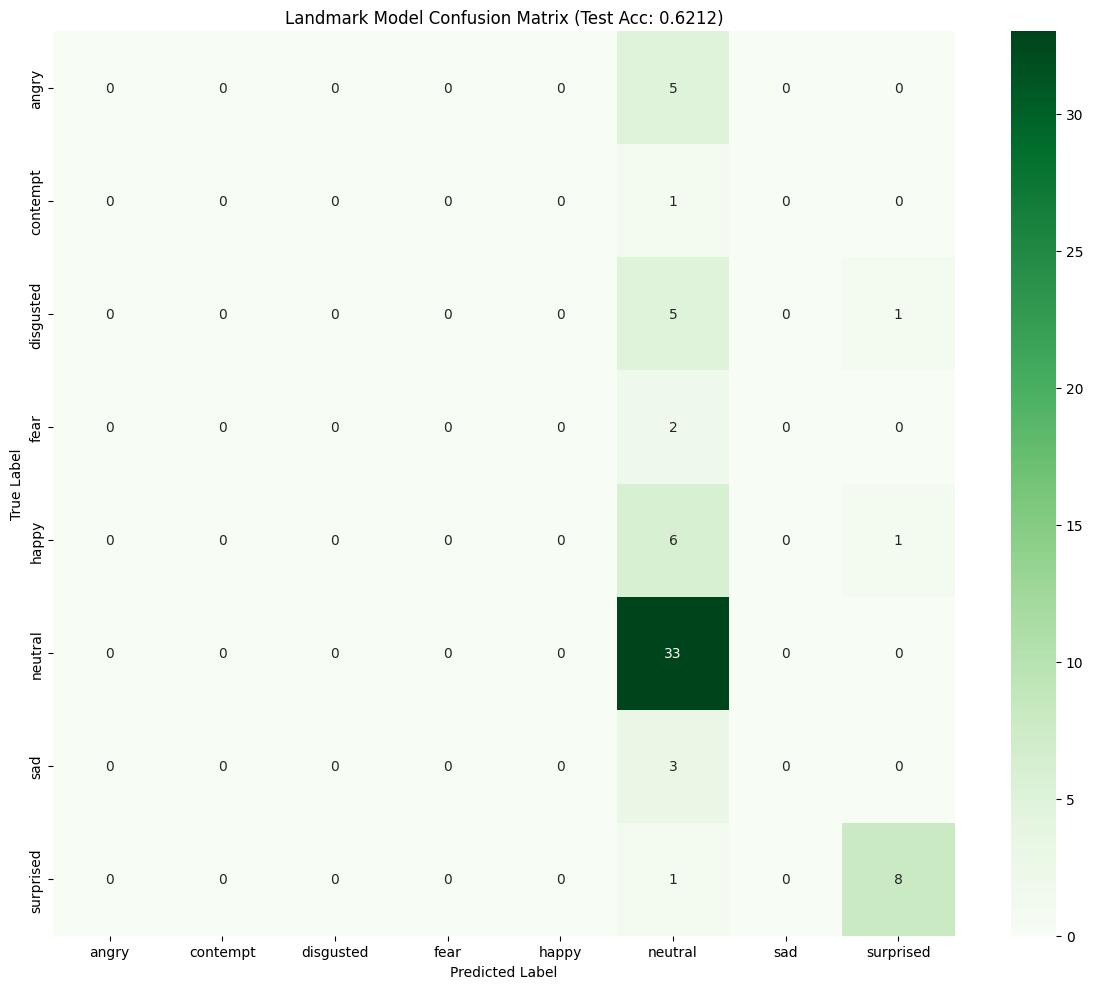

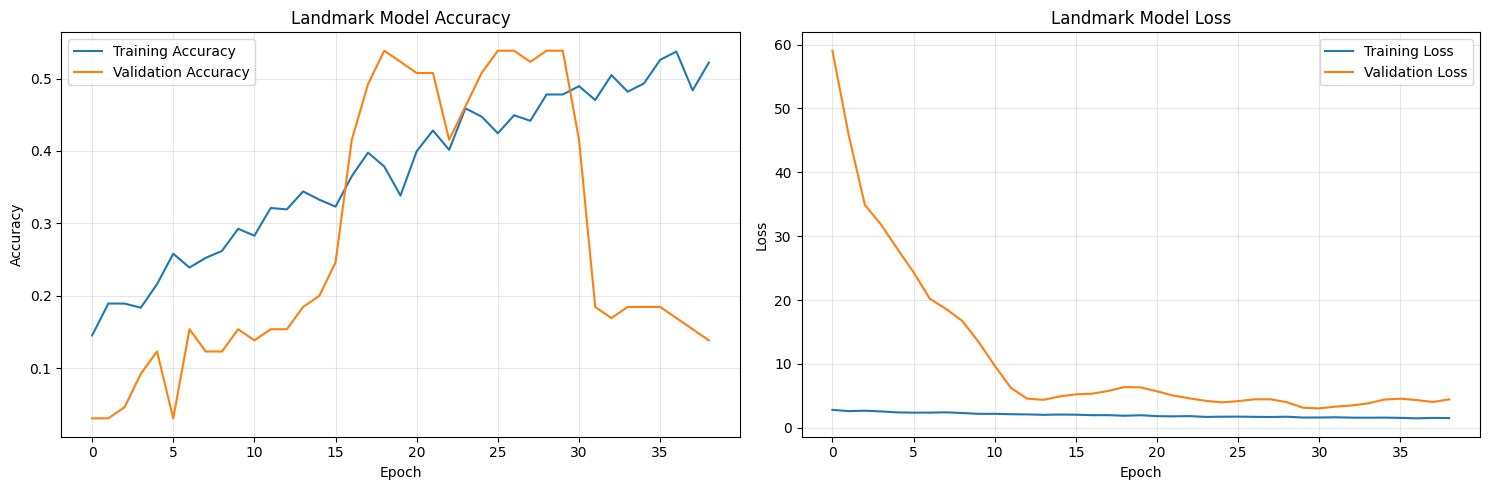

In [49]:
print("📊 Creating visualizations...")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
           xticklabels=target_names, yticklabels=target_names)
plt.title(f'Landmark Model Confusion Matrix (Test Acc: {test_acc:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(MODEL_PATH + 'landmark_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Training history
if 'landmark_history' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(landmark_history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(landmark_history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Landmark Model Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(landmark_history.history['loss'], label='Training Loss')
    axes[1].plot(landmark_history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Landmark Model Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(MODEL_PATH + 'landmark_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

## 11. 💾 Save Results

In [50]:
print("💾 Saving results...")

# Save training info
training_info = {
    'model_type': 'Landmark',
    'gpu_used': gpu_available,
    'num_gpus': num_gpus,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(landmark_history.history['accuracy']) if 'landmark_history' in locals() else 0,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'total_parameters': landmark_model.count_params(),
    'training_time_hours': training_time/3600 if 'training_time' in locals() else 0,
    'device_info': f"AMD GPU ({num_gpus} device(s))" if gpu_available else "CPU"
}

with open(MODEL_PATH + 'landmark_training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

💾 Saving results...


## 12. 📝 Summary

In [51]:
print("\n" + "=" * 60)
print("🎉 LANDMARK TRAINING COMPLETED!")
print("=" * 60)
print(f"📊 Final Test Accuracy: {test_acc:.4f}")
print(f"🎮 Device Used: {'AMD GPU' if gpu_available else 'CPU'}")
print(f"⏱️ Training Time: {training_time/3600:.2f} hours" if 'training_time' in locals() else "N/A")
print(f"💾 Model saved to: {MODEL_PATH}landmark_model_best.h5")
print(f"📈 Visualizations saved to: {MODEL_PATH}")
print("\n🚀 Ready for next step: Late Fusion!")
print("=" * 60)


🎉 LANDMARK TRAINING COMPLETED!
📊 Final Test Accuracy: 0.6212
🎮 Device Used: AMD GPU
⏱️ Training Time: 0.01 hours
💾 Model saved to: D:/research/2025_iris_taufik/MultimodalEmoLearn/models/landmark_model_best.h5
📈 Visualizations saved to: D:/research/2025_iris_taufik/MultimodalEmoLearn/models/

🚀 Ready for next step: Late Fusion!
